# ML4T Library: Market Impact Models

**Docker image**: `ml4t`

The previous notebooks derived impact models by hand. A backtest needs them as code it can call
on every fill, and `ml4t.backtest.execution` provides four:

1. **NoImpact** charges nothing, which is what a backtest does by default and why backtests
   flatter strategies that trade a lot.
2. **LinearImpact** charges in proportion to the participation rate.
3. **SquareRootImpact** charges in proportion to volatility times the square root of
   participation, which is the shape `03_market_impact_calibration` argues for.
4. **PowerLawImpact** takes the exponent as a parameter, so it covers both of the above and
   everything between.

All four answer the same question - given an order of this size against this much volume, how far
does the price move against me - and all four return a **signed per-share price move**: positive
for a buy, negative for a sell, so that adding it to the decision price always makes the fill
worse. What separates them is the shape of the relationship and the parameters that scale it.

**Learning Objectives**
- Call any of the four models through one interface and read the sign convention correctly
- Separate what an impact model's exponent decides from what its coefficient decides, and see why
  two models' levels cannot be compared until their coefficients are put on the same footing
- Compose an impact model with a participation limit to produce the fill a backtest would record
- Substitute a measured volatility into a model whose coefficient you have not measured, and say
  what that does and does not establish
- Recognize that these models are stateless, and supply persistence across child orders yourself
  when you need it

**Book Reference:** Chapter 18, Section 18.4

**Prerequisites:** Read
[`03_market_impact_calibration`](03_market_impact_calibration.ipynb) for the economic meaning of
impact coefficients and
[`07_ml4t_volume_participation`](07_ml4t_volume_participation.ipynb) for quantity constraints per
bar.

## Imports & Setup

In [1]:
"""ML4T Library: Market Impact Models - Comparing impact model APIs for backtesting."""

from datetime import timedelta

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from ml4t.backtest.execution.impact import (
    LinearImpact,
    MarketImpactModel,
    NoImpact,
    PowerLawImpact,
    SquareRootImpact,
)
from ml4t.backtest.execution.limits import VolumeParticipationLimit
from ml4t.backtest.execution.result import ExecutionResult

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_plotly_with_alt

In [2]:
SEED = 42
UNIVERSE = ["SPY", "QQQ", "IWM", "EEM", "DBC"]
LOOKBACK_DAYS = 365
IMPACT_COEFFICIENT = 0.5
SCENARIO_VOLATILITY = 0.02
MAX_PARTICIPATION = 0.10
PARAMETERIZATION_PARTICIPATION = 0.05
PERSISTENCE_FRACTION = 0.50

In [3]:
set_global_seeds(SEED)

What each setting decides:

- `UNIVERSE` and `LOOKBACK_DAYS` fix the five ETFs and the trailing window their prices, volumes
  and volatilities are measured over. The five span a range of volatility wide enough that the
  model's volatility term visibly changes the answer.
- `IMPACT_COEFFICIENT` is the library's own default for the square-root model. It is a stated
  figure and every impact level in this notebook scales directly with it.
- `SCENARIO_VOLATILITY` is the daily volatility used wherever a single round number is wanted
  instead of a measured one, so the scenario sections stay comparable with each other.
- `MAX_PARTICIPATION` caps how much of a bar's volume one order may take. Anything above it is
  filled partially and the remainder is carried, which is what a backtest must do rather than
  pretending an unlimited order filled at one price.
- `PARAMETERIZATION_PARTICIPATION` is the fixed rate at which the five ETFs are compared, so that
  the only thing differing between them is their measured volatility.
- `PERSISTENCE_FRACTION` is the share of each child order's impact that the notebook carries into
  the next child's reference price. The library models are stateless and do not do this; the
  value is the notebook's own assumption.

## Part 1: Understanding the Impact Model API

All impact models inherit from `MarketImpactModel` and implement a single method:

```python
def calculate(
    self,
    quantity: float,    # Order quantity (shares)
    price: float,       # Current market price
    volume: float,      # Bar volume (daily, minute, etc.)
    is_buy: bool,       # Trade direction
) -> float:            # Signed per-share price move
```

The return is a **signed per-share price move** in currency units, not basis points: positive for
buys and negative for sells, so adding it to the decision price always moves the fill against the
trader. Its absolute value is the per-share cost.

The `volume` argument deserves care, because it is where look-ahead enters a backtest most
easily. A bar's total volume is known only once the bar has closed, so sizing an order against it
uses information the order did not have. Use volume accumulated so far, a lagged or forecast
figure, or execute on the following bar. Every example below supplies volume as a stated scenario
input rather than reading it from a bar the order is supposedly trading inside.

These models are also **stateless**: each call sees one order and knows nothing about the ones
before it. That matters for a parent order worked in slices, because permanent impact - the part
of the move that does not revert - should be paid again by every later slice. Part 4 supplies
that persistence explicitly, outside the model.

In [4]:
# Instantiate all four models with default parameters
models = {
    "NoImpact": NoImpact(),
    "LinearImpact": LinearImpact(coefficient=0.1, permanent_fraction=0.5),
    "SquareRootImpact": SquareRootImpact(
        coefficient=IMPACT_COEFFICIENT, volatility=SCENARIO_VOLATILITY
    ),
    "PowerLawImpact": PowerLawImpact(coefficient=0.1, exponent=0.5),
}

# Sample trade parameters
price = 100.0
volume = 1_000_000  # Daily volume
is_buy = True

# Impact (price units) at 1% / 5% / 10% participation, buying a $100 stock vs 1M ADV
impact_comparison = pl.DataFrame(
    [
        {
            "model": name,
            "impact_per_share_1pct_usd": model.calculate(volume * 0.01, price, volume, is_buy),
            "impact_per_share_5pct_usd": model.calculate(volume * 0.05, price, volume, is_buy),
            "impact_per_share_10pct_usd": model.calculate(volume * 0.10, price, volume, is_buy),
        }
        for name, model in models.items()
    ]
)
impact_comparison

model,impact_per_share_1pct_usd,impact_per_share_5pct_usd,impact_per_share_10pct_usd
str,f64,f64,f64
"""NoImpact""",0.0,0.0,0.0
"""LinearImpact""",0.1,0.5,1.0
"""SquareRootImpact""",0.1,0.223607,0.316228
"""PowerLawImpact""",1.0,2.236068,3.162278


**Finding**: Model levels are not comparable until their coefficients, volatility inputs, and
volume conventions are aligned. This table is an API and unit check; it shows how the illustrative
parameterizations differ rather than which model is most accurate.

## Part 2: Model Deep Dive

### LinearImpact

$$\text{Impact} = \text{coefficient} \times \frac{Q}{V} \times P$$

- Simple, intuitive model
The coefficient is the whole model. It is the per-share concession, as a fraction of price, that
an order equal to the market's entire volume would pay, and every smaller order pays that
fraction scaled down in proportion. Multiply the coefficient by ten thousand to read it as the
cost in basis points at full participation.

In [5]:
# LinearImpact sensitivity analysis
linear = LinearImpact(coefficient=0.1)

participation_rates = np.linspace(0.001, 0.20, 100)
quantities = participation_rates * volume

linear_impacts = [linear.calculate(q, price, volume, is_buy) for q in quantities]
print(f"LinearImpact with coefficient {linear.coefficient}, buying a ${price:.0f} stock:")
for participation in (0.01, 0.10, 1.00):
    impact = linear.calculate(volume * participation, price, volume, is_buy)
    print(
        f"  {participation:>5.0%} of volume -> ${impact:.4f} per share, "
        f"{impact / price * 10_000:>6.0f} bps"
    )

LinearImpact with coefficient 0.1, buying a $100 stock:
     1% of volume -> $0.1000 per share,     10 bps
    10% of volume -> $1.0000 per share,    100 bps
   100% of volume -> $10.0000 per share,   1000 bps


**Reading the output**: The three lines are exactly proportional, which is the model. That makes
it easy to sanity-check - at full participation the cost in basis points is the coefficient times
ten thousand - and it is also its weakness. Proportionality means the last share of a large order
costs the same as the first, which contradicts what the square-root shape in
`03_market_impact_calibration` was fitted to.

### SquareRootImpact (Almgren-Chriss)

$$\text{Impact} = \text{coefficient} \times \sigma \times \sqrt{\frac{Q}{ADV}} \times P$$

- Common research-motivated baseline across asset classes
Two things scale this model. The `coefficient` plays the same role as the linear model's, and
`volatility` is the instrument's daily standard deviation of returns, which sets how much a given
amount of participation costs in a market that moves a lot against one that does not.
`adv_factor` converts the `volume` argument into an average daily volume when the bars are
shorter than a day: it is the number of bars in a session, so it stays at one for daily bars.

In [6]:
# SquareRootImpact with different volatility regimes
sqrt_low_vol = SquareRootImpact(coefficient=IMPACT_COEFFICIENT, volatility=SCENARIO_VOLATILITY / 2)
sqrt_mid_vol = SquareRootImpact(coefficient=IMPACT_COEFFICIENT, volatility=SCENARIO_VOLATILITY)
sqrt_high_vol = SquareRootImpact(coefficient=IMPACT_COEFFICIENT, volatility=SCENARIO_VOLATILITY * 2)

sqrt_impacts_low = [sqrt_low_vol.calculate(q, price, volume, is_buy) for q in quantities]
sqrt_impacts_mid = [sqrt_mid_vol.calculate(q, price, volume, is_buy) for q in quantities]
sqrt_impacts_high = [sqrt_high_vol.calculate(q, price, volume, is_buy) for q in quantities]
sqrt_10pct_low = sqrt_low_vol.calculate(volume * 0.10, price, volume, is_buy)
sqrt_10pct_mid = sqrt_mid_vol.calculate(volume * 0.10, price, volume, is_buy)
sqrt_10pct_high = sqrt_high_vol.calculate(volume * 0.10, price, volume, is_buy)

print(f"SquareRootImpact with coefficient {IMPACT_COEFFICIENT}, at the same participation:")
for model, impact in (
    (sqrt_low_vol, sqrt_10pct_low),
    (sqrt_mid_vol, sqrt_10pct_mid),
    (sqrt_high_vol, sqrt_10pct_high),
):
    print(
        f"  volatility {model.volatility:.1%} a day: ${impact:.4f} per share, "
        f"{impact / price * 10_000:.1f} bps"
    )

SquareRootImpact with coefficient 0.5, at the same participation:
  volatility 1.0% a day: $0.1581 per share, 15.8 bps
  volatility 2.0% a day: $0.3162 per share, 31.6 bps
  volatility 4.0% a day: $0.6325 per share, 63.2 bps


**Reading the output**: Doubling the volatility doubles the cost, at every participation rate,
because volatility enters the model as a plain multiplier. That is what makes this model
responsive to market conditions in a way the linear one is not: the same order in the same
instrument costs more in a week when the price is moving, without anything about the order or
the instrument's liquidity having changed.

### PowerLawImpact

$$\text{Impact} = \text{coefficient} \times \left(\frac{Q}{V}\right)^{\text{exponent}} \times P$$

The exponent is what the other two models fix and this one exposes. Set it to one and the model
is the linear one; set it to a half and it is the square-root one. Any exponent between zero and
one makes the curve concave, so each additional unit of participation costs less than the last,
and an exponent above one makes it convex, so each costs more.
- `min_impact` is a minimum absolute per-share price move, not a fixed dollar trade cost

In [7]:
# PowerLawImpact with different exponents
power_linear = PowerLawImpact(coefficient=0.1, exponent=1.0)  # Same as LinearImpact
power_sqrt = PowerLawImpact(coefficient=0.1, exponent=0.5)
power_concave = PowerLawImpact(coefficient=0.1, exponent=0.3)
power_mild_concave = PowerLawImpact(coefficient=0.1, exponent=0.8)

power_impacts_linear = [power_linear.calculate(q, price, volume, is_buy) for q in quantities]
power_impacts_sqrt = [power_sqrt.calculate(q, price, volume, is_buy) for q in quantities]
power_impacts_concave = [power_concave.calculate(q, price, volume, is_buy) for q in quantities]
power_impacts_mild_concave = [
    power_mild_concave.calculate(q, price, volume, is_buy) for q in quantities
]
power_10pct_linear = power_linear.calculate(volume * 0.10, price, volume, is_buy)
power_10pct_sqrt = power_sqrt.calculate(volume * 0.10, price, volume, is_buy)
power_10pct_concave = power_concave.calculate(volume * 0.10, price, volume, is_buy)

print(f"PowerLawImpact with coefficient {power_linear.coefficient}, at the same participation:")
for model, impact, shape in (
    (power_linear, power_10pct_linear, "linear"),
    (power_sqrt, power_10pct_sqrt, "square root"),
    (power_concave, power_10pct_concave, "strongly concave"),
):
    print(
        f"  exponent {model.exponent}: ${impact:.4f} per share, "
        f"{impact / price * 10_000:.1f} bps ({shape})"
    )

PowerLawImpact with coefficient 0.1, at the same participation:
  exponent 1.0: $1.0000 per share, 100.0 bps (linear)
  exponent 0.5: $3.1623 per share, 316.2 bps (square root)
  exponent 0.3: $5.0119 per share, 501.2 bps (strongly concave)


**Finding**: Every exponent between zero and one is concave; smaller exponents bend the curve
more strongly. For participation below one, a smaller exponent also raises the level when the
coefficient is held fixed, so curvature and coefficient must be chosen or estimated jointly.

## Part 3: Visual Comparison

The first chart compares the illustrative parameter sets used above. Its levels are not a model
ranking: `SquareRootImpact` includes volatility in its scale, while `PowerLawImpact` does not.

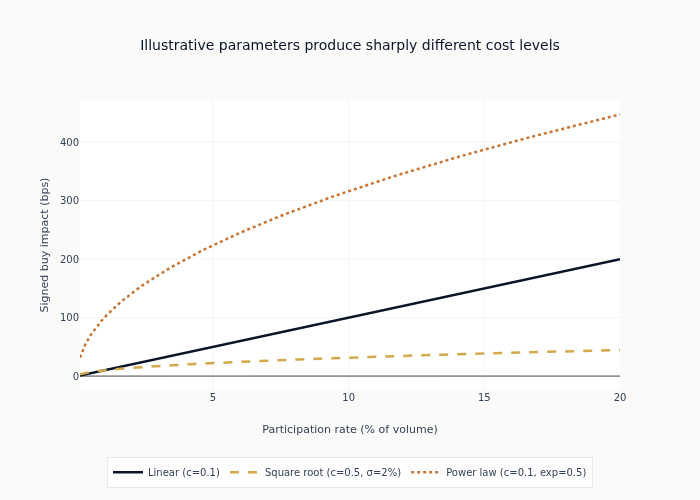

In [8]:
fig = go.Figure()
comparison_specs = (
    ("Linear (c=0.1)", linear_impacts, COLORS["blue"], "solid"),
    ("Square root (c=0.5, σ=2%)", sqrt_impacts_mid, COLORS["amber"], "dash"),
    ("Power law (c=0.1, exp=0.5)", power_impacts_sqrt, COLORS["copper"], "dot"),
)
for label, impacts, color, dash in comparison_specs:
    fig.add_scatter(
        x=participation_rates * 100,
        y=[impact / price * 10000 for impact in impacts],
        mode="lines",
        name=label,
        line=dict(width=2.5, color=color, dash=dash),
    )
fig.update_layout(
    title="Illustrative parameters produce sharply different cost levels",
    xaxis_title="Participation rate (% of volume)",
    yaxis_title="Signed buy impact (bps)",
    height=500,
    legend=dict(orientation="h", y=-0.23, x=0.5, xanchor="center"),
    margin=dict(b=105),
)
show_plotly_with_alt(
    fig,
    "Three impact curves against participation rate. All rise and flatten, but they sit at "
    "visibly different levels despite two of them sharing the same square-root shape.",
)

**Reading the chart**: Functional form alone does not rank cost severity. The power-law curve
sits above the square-root curve here even though the two have the identical shape, because one
of them multiplies by a volatility and the other does not, and their coefficients are on
different footings as a result. A reader who took the higher curve to be the more pessimistic
model would be reading the coefficients, not the models.

### Volatility Sets Scale

The coefficient is held at the library's default and only the volatility varies, so the three
curves differ by exactly the factor their volatilities differ by. This gets its own chart because
its vertical scale is not comparable with the power-law chart that follows.

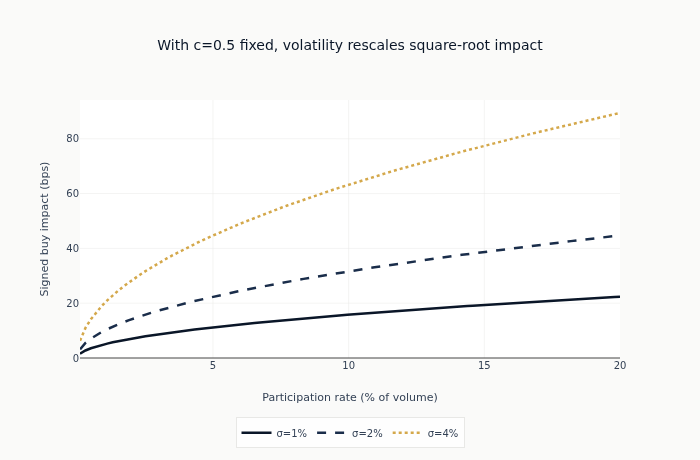

In [9]:
volatility_fig = go.Figure()
vol_specs = (
    ("σ=1%", sqrt_impacts_low, COLORS["blue"], "solid"),
    ("σ=2%", sqrt_impacts_mid, COLORS["slate"], "dash"),
    ("σ=4%", sqrt_impacts_high, COLORS["amber"], "dot"),
)
for label, impacts, color, dash in vol_specs:
    volatility_fig.add_scatter(
        x=participation_rates * 100,
        y=[impact / price * 10000 for impact in impacts],
        mode="lines",
        name=label,
        line=dict(width=2.5, color=color, dash=dash),
    )
volatility_fig.update_layout(
    title="With c=0.5 fixed, volatility rescales square-root impact",
    xaxis_title="Participation rate (% of volume)",
    yaxis_title="Signed buy impact (bps)",
    height=460,
    legend=dict(orientation="h", y=-0.23, x=0.5, xanchor="center"),
    margin=dict(b=100),
)
volatility_fig.update_yaxes(rangemode="tozero")
show_plotly_with_alt(
    volatility_fig,
    "Three square-root impact curves, one per volatility, identical in shape and stacked in "
    "proportion to the volatility that scales them.",
)

### The Exponent Sets Curvature

Now the coefficient is held and only the exponent varies. Every exponent shown is between zero
and one, so every curve is concave; the ones nearer to one are only mildly so, which is easy to
misread as convexity when a curve is close to straight.

In [10]:
exponent_specs = (
    ("exp=1.0 (linear)", power_impacts_linear, COLORS["neutral"], "solid"),
    ("exp=0.8", power_impacts_mild_concave, COLORS["blue"], "dash"),
    ("exp=0.5", power_impacts_sqrt, COLORS["copper"], "dot"),
    ("exp=0.3", power_impacts_concave, COLORS["amber"], "dashdot"),
)
exponent_fig = go.Figure()
for label, impacts, color, dash in exponent_specs:
    exponent_fig.add_scatter(
        x=participation_rates * 100,
        y=[impact / price * 10000 for impact in impacts],
        mode="lines",
        name=label,
        line=dict(width=2.5, color=color, dash=dash),
    )

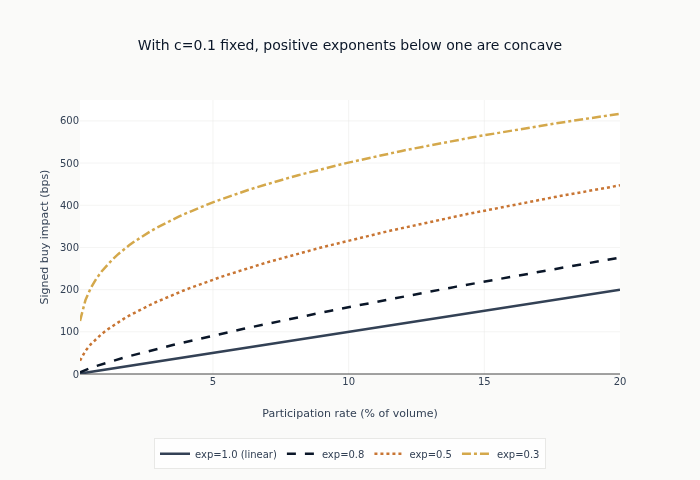

In [11]:
exponent_fig.update_layout(
    title="With c=0.1 fixed, positive exponents below one are concave",
    xaxis_title="Participation rate (% of volume)",
    yaxis_title="Signed buy impact (bps)",
    height=480,
    legend=dict(orientation="h", y=-0.23, x=0.5, xanchor="center"),
    margin=dict(b=105),
)
exponent_fig.update_yaxes(rangemode="tozero")
show_plotly_with_alt(
    exponent_fig,
    "Four power-law impact curves sharing a coefficient. The exponent-one curve is a straight "
    "line; smaller exponents bow further above it and rise more steeply near zero participation.",
)

**Finding**: Doubling volatility doubles square-root impact at every participation rate. Changing
a positive exponent below one changes concavity, but a coefficient comparison is still required
before one shape can be called more expensive than another.

## Part 4: Trade Sequence Simulation

A parent order is worked in equal child orders against a fixed daily volume. Because the models
have no memory, the notebook carries a stated fraction of each child's impact into the next
child's reference price itself - see `PERSISTENCE_FRACTION` above. That fraction is the
notebook's assumption and not something the library tracks, and it is applied identically to
every model so the comparison between them is unaffected by it.

In [12]:
# Trade sequence simulation
total_shares = 100_000
price = 100.0
adv_shares = 1_000_000
n_child_orders = 10
shares_per_order = total_shares / n_child_orders

# Models to compare
simulation_models = {
    "NoImpact": NoImpact(),
    "LinearImpact": LinearImpact(coefficient=0.1),
    "SquareRootImpact": SquareRootImpact(
        coefficient=IMPACT_COEFFICIENT, volatility=SCENARIO_VOLATILITY
    ),
    "PowerLawImpact": PowerLawImpact(coefficient=0.1, exponent=0.6),
}

### Simulate Multi-Order Execution

In [13]:
# Simulate execution
results = []
for model_name, model in simulation_models.items():
    exec_price = price
    total_cost = 0.0
    fill_prices = []

    for i in range(n_child_orders):
        # Each 10,000-share child is measured against the full 1,000,000-share ADV.
        impact = model.calculate(shares_per_order, exec_price, adv_shares, is_buy=True)

        # Fill at impacted price
        fill_price = exec_price + impact
        fill_prices.append(fill_price)

        # Cost for this fill
        order_cost = (fill_price - price) * shares_per_order
        total_cost += order_cost

        # Carry the stated scenario fraction into the next child order.
        exec_price = exec_price + impact * PERSISTENCE_FRACTION

        results.append(
            {
                "model": model_name,
                "order": i + 1,
                "fill_price": fill_price,
                "impact_per_share_usd": impact,
                "cumulative_cost": total_cost,
            }
        )

results_df = pl.DataFrame(results)

### First-Child Unit Oracle

The linear model is simple enough to check by hand, which makes it the right place to confirm
the units before trusting anything downstream. The first child's participation is its share count
divided by the daily volume, and the linear model's signed move must equal the coefficient times
that participation times the price. The cell below computes both sides and raises if they differ.

In [14]:
first_linear = results_df.filter((pl.col("model") == "LinearImpact") & (pl.col("order") == 1)).row(
    0, named=True
)
first_child_participation = shares_per_order / adv_shares
first_child_impact_per_share = first_linear["impact_per_share_usd"]
expected_impact = LinearImpact().coefficient * first_child_participation * price
if not np.isclose(first_child_impact_per_share, expected_impact):
    raise ValueError("Library linear impact disagrees with coefficient x participation x price")
display(
    Markdown(
        f"**Unit check:** the first child is **{shares_per_order:,.0f} shares** against "
        f"**{adv_shares:,.0f}** of daily volume, a participation rate of "
        f"**{first_child_participation:.1%}**. The library returns "
        f"**${first_child_impact_per_share:.4f} per share**, which is "
        f"**{first_child_impact_per_share / price * 10_000:.1f} bps** of the "
        f"**${price:.0f}** reference price and matches the hand calculation exactly."
    )
)

**Unit check:** the first child is **10,000 shares** against **1,000,000** of daily volume, a participation rate of **1.0%**. The library returns **$0.1000 per share**, which is **10.0 bps** of the **$100** reference price and matches the hand calculation exactly.

### Sequence-Level Cost Summary

In [15]:
# Sequence cost summary: 100,000 shares @ $100
sequence_summary_rows = []
for model_name in simulation_models.keys():
    model_data = results_df.filter(pl.col("model") == model_name)
    final_cost = model_data["cumulative_cost"][-1]
    sequence_summary_rows.append(
        {
            "model": model_name,
            "vwap_usd": price + final_cost / total_shares,
            "total_cost_usd": final_cost,
            "cost_bps": final_cost / (price * total_shares) * 10000,
        }
    )
sequence_summary = pl.DataFrame(sequence_summary_rows)
sequence_summary

model,vwap_usd,total_cost_usd,cost_bps
str,f64,f64,f64
"""NoImpact""",100.0,0.0,0.0
"""LinearImpact""",100.325526,32552.556292,32.552556
"""SquareRootImpact""",100.325526,32552.556292,32.552556
"""PowerLawImpact""",102.071654,207165.395752,207.165396


**Finding**: The sequence summary holds the parent order, child schedule, and assumed persistence
fixed. Differences therefore come from the illustrative model parameterizations, not from the
library maintaining cumulative state.

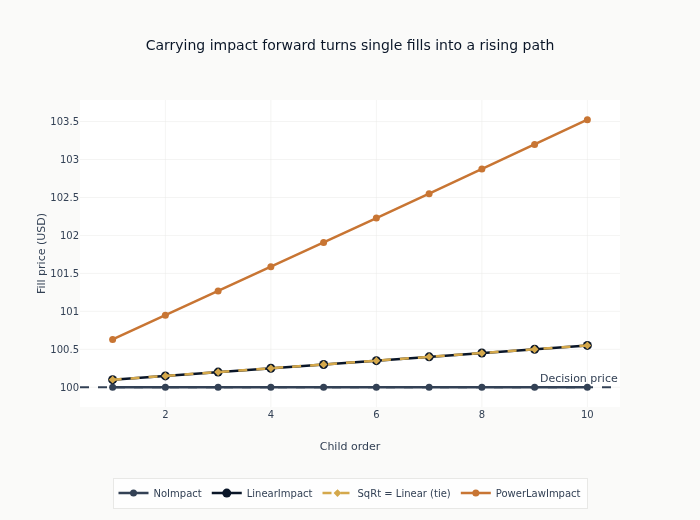

In [16]:
# Visualize execution paths
fig = go.Figure()
sequence_colors = {
    "NoImpact": COLORS["neutral"],
    "LinearImpact": COLORS["blue"],
    "SquareRootImpact": COLORS["amber"],
    "PowerLawImpact": COLORS["copper"],
}
sequence_dashes = {
    "NoImpact": "solid",
    "LinearImpact": "solid",
    "SquareRootImpact": "dash",
    "PowerLawImpact": "solid",
}
sequence_markers = {
    "NoImpact": (7, "circle"),
    "LinearImpact": (9, "circle"),
    "SquareRootImpact": (6, "diamond"),
    "PowerLawImpact": (7, "circle"),
}
for model_name in simulation_models:
    model_data = results_df.filter(pl.col("model") == model_name)
    marker_size, marker_symbol = sequence_markers[model_name]
    label = "SqRt = Linear (tie)" if model_name == "SquareRootImpact" else model_name
    fig.add_scatter(
        x=model_data["order"].to_list(),
        y=model_data["fill_price"].to_list(),
        mode="lines+markers",
        name=label,
        line=dict(width=2.5, color=sequence_colors[model_name], dash=sequence_dashes[model_name]),
        marker=dict(size=marker_size, symbol=marker_symbol),
    )

fig.add_hline(
    y=price,
    line_dash="dash",
    line_color=COLORS["neutral"],
    annotation_text="Decision price",
)

fig.update_layout(
    title="Carrying impact forward turns single fills into a rising path",
    xaxis_title="Child order",
    yaxis_title="Fill price (USD)",
    height=520,
    legend=dict(orientation="h", y=-0.23, x=0.5, xanchor="center"),
    margin=dict(b=105),
)
show_plotly_with_alt(
    fig,
    "Fill price against child-order number for four models, all starting at the dashed decision "
    "price. NoImpact stays flat; the other three rise steadily, with the linear and square-root "
    "paths lying exactly on top of each other.",
)

**Reading the chart**: Carrying half of each slice's impact into the next slice's reference price
is what makes the fills climb. Without it every child would fill at the same price, because the
models have no memory of the ones before.

The linear and square-root paths lie on top of each other, and that is worth pausing on rather
than passing over. Every child order here is the same fraction of volume, and at that particular
fraction the two parameterizations happen to charge the same amount: the linear coefficient times
the participation rate equals the square-root coefficient times the volatility times the square
root of the same rate. They agree at that one participation rate and nowhere else - the matching
used
deliberately in `05_almgren_chriss_optimal_execution` to compare two shapes without a level
difference confusing the comparison. A schedule that varied its participation would pull them
apart immediately.

## Part 5: A Real Universe to Price Orders Against

Every number so far has been a round scenario. The rest of the notebook prices orders against
five real ETFs - their traded prices, their volumes, and the volatility measured from their
returns - so that the participation rates and the resulting costs are ones a reader could
actually face.

The five are fixed by name and the window is the trailing year of the dataset. That is a
retrospective teaching sample, not a universe anyone selected in advance, and nothing in this
notebook is held out from anything.

In [17]:
etf_data = load_etfs()

max_date = etf_data["timestamp"].max()
if max_date is None:
    raise ValueError("ETF dataset is empty; cannot parameterize impact models.")
min_date = max_date - timedelta(days=LOOKBACK_DAYS)
etf_filtered = etf_data.filter(
    (pl.col("symbol").is_in(UNIVERSE)) & (pl.col("timestamp") >= min_date)
)
missing_symbols = sorted(set(UNIVERSE) - set(etf_filtered["symbol"].unique().to_list()))
if missing_symbols:
    raise ValueError(f"Missing required ETF symbols: {missing_symbols}")

### Compute Descriptive Inputs in Polars

Three quantities per symbol drive everything that follows: the average traded price, the average
daily volume that a participation rate is a fraction of, and the standard deviation of daily
returns, which is the volatility the square-root model scales by. The high-low range is reported
alongside as a second view of how much each fund moves; it is not a spread and is not passed to
any model.

In [18]:
etf_stats = (
    etf_filtered.sort(["symbol", "timestamp"])
    .with_columns(daily_return=pl.col("close").pct_change().over("symbol"))
    .group_by("symbol")
    .agg(
        observations=pl.len(),
        avg_price=pl.col("close").mean(),
        avg_volume=pl.col("volume").mean(),
        daily_volatility=pl.col("daily_return").std(),
        avg_high_low_range_bps=((pl.col("high") / pl.col("low") - 1) * 10_000).mean(),
    )
    .with_columns(annualized_volatility=pl.col("daily_volatility") * np.sqrt(252))
    .sort("symbol")
)
etf_stats

symbol,observations,avg_price,avg_volume,daily_volatility,avg_high_low_range_bps,annualized_volatility
str,u32,f64,f64,f64,f64,f64
"""DBC""",251,21.445646,872066.932271,0.009635,88.954374,0.152957
"""EEM""",251,47.492689,2.6052e7,0.011104,89.753988,0.17627
"""IWM""",251,221.74921,3.5313e7,0.014396,172.510733,0.228524
"""QQQ""",251,546.574928,4.8584e7,0.014865,151.624061,0.235971
"""SPY""",251,614.052782,7.2384e7,0.012275,119.279747,0.194867


In [19]:
display(
    Markdown(
        f"The sample covers **{etf_filtered['symbol'].n_unique()} ETFs** from "
        f"**{etf_filtered['timestamp'].min():%Y-%m-%d}** through "
        f"**{etf_filtered['timestamp'].max():%Y-%m-%d}**, and their daily volatilities span "
        f"**{etf_stats['daily_volatility'].min():.2%}** to "
        f"**{etf_stats['daily_volatility'].max():.2%}**."
    )
)

The sample covers **5 ETFs** from **2024-12-31** through **2025-12-31**, and their daily volatilities span **0.96%** to **1.49%**.

## Part 6: Backtest Integration Pattern

`FillExecutor` consumes the limit's `ExecutionResult` internally, uses its fillable quantity,
applies the signed impact once to the base price, applies slippage, and emits a `Fill` whose
`price` includes those adjustments. The limit result's `adjusted_price` and `impact_cost` remain
placeholders. The helper below exposes the intermediate limit-plus-impact arithmetic in an
`ExecutionResult`-shaped record for teaching; it is not the production executor's return value.

### Expose Limit-plus-Impact Arithmetic

In [20]:
def compose_limit_and_impact(
    quantity: float,
    side: str,
    decision_price: float,
    volume: float,
    impact_model: MarketImpactModel,
    max_participation: float,
) -> ExecutionResult:
    """Expose one limit-plus-impact calculation in an inspection record."""
    if side not in {"buy", "sell"}:
        raise ValueError("side must be 'buy' or 'sell'")
    if volume <= 0:
        raise ValueError("volume must be positive")

    is_buy = side == "buy"
    limit_result = VolumeParticipationLimit(max_participation=max_participation).calculate(
        abs(quantity), volume, decision_price
    )
    fillable = limit_result.fillable_quantity
    remaining = limit_result.remaining_quantity

    impact = impact_model.calculate(
        quantity=fillable,
        price=decision_price,
        volume=volume,
        is_buy=is_buy,
    )
    adjusted_price = decision_price + impact
    return ExecutionResult(
        fillable_quantity=fillable,
        remaining_quantity=remaining,
        adjusted_price=adjusted_price,
        impact_cost=abs(impact) * fillable,
        participation_rate=limit_result.participation_rate,
    )

### An Order Book Built from the Real Panel

One order per ETF, alternating side, each sized as a stated multiple of that fund's own average
daily volume. Sizing by participation rather than by share count is what makes the five orders
comparable across funds whose volumes differ by orders of magnitude, and it puts two of them
above the participation cap on purpose so the partial-fill path is exercised.

In [21]:
order_participations = [0.05, 0.10, 0.15, 0.08, 0.20]
trades_data = [
    (
        row["symbol"],
        row["avg_volume"] * participation,
        "buy" if index % 2 == 0 else "sell",
        row["avg_price"],
        row["avg_volume"],
    )
    for index, (row, participation) in enumerate(
        zip(etf_stats.iter_rows(named=True), order_participations, strict=True)
    )
]
pl.DataFrame(
    trades_data,
    schema=["symbol", "order_shares", "side", "decision_price", "daily_volume"],
    orient="row",
)

symbol,order_shares,side,decision_price,daily_volume
str,f64,str,f64,f64
"""DBC""",43603.346614,"""buy""",21.445646,872066.932271
"""EEM""",2.6052e6,"""sell""",47.492689,2.6052e7
"""IWM""",5.2969e6,"""buy""",221.74921,3.5313e7
"""QQQ""",3.8867e6,"""sell""",546.574928,4.8584e7
"""SPY""",1.4477e7,"""buy""",614.052782,7.2384e7


### Compare No-Impact vs Square-Root Impact

In [22]:
integration_rows = []
for model_name, impact_model in [
    ("NoImpact", NoImpact()),
    (
        "SquareRootImpact",
        SquareRootImpact(coefficient=IMPACT_COEFFICIENT, volatility=SCENARIO_VOLATILITY),
    ),
]:
    for symbol, qty, side, decision_price, volume in trades_data:
        result = compose_limit_and_impact(
            qty, side, decision_price, volume, impact_model, MAX_PARTICIPATION
        )
        integration_rows.append(
            {
                "model": model_name,
                "symbol": symbol,
                "side": side,
                "decision_price": decision_price,
                "fillable_qty": result.fillable_quantity,
                "remaining_qty": result.remaining_quantity,
                "is_partial": result.is_partial,
                "adjusted_price": result.adjusted_price,
                "participation_rate": result.participation_rate,
                "total_impact_cost_usd": result.impact_cost,
            }
        )

integration_results = pl.DataFrame(integration_rows)
integration_results

model,symbol,side,decision_price,fillable_qty,remaining_qty,is_partial,adjusted_price,participation_rate,total_impact_cost_usd
str,str,str,f64,f64,f64,bool,f64,f64,f64
"""NoImpact""","""DBC""","""buy""",21.445646,43603.346614,0.0,false,21.445646,0.05,0.0
"""NoImpact""","""EEM""","""sell""",47.492689,2.6052e6,0.0,false,47.492689,0.1,0.0
"""NoImpact""","""IWM""","""buy""",221.74921,3.5313e6,1.7656e6,true,221.74921,0.1,0.0
"""NoImpact""","""QQQ""","""sell""",546.574928,3.8867e6,0.0,false,546.574928,0.08,0.0
"""NoImpact""","""SPY""","""buy""",614.052782,7.2384e6,7.2384e6,true,614.052782,0.1,0.0
"""SquareRootImpact""","""DBC""","""buy""",21.445646,43603.346614,0.0,false,21.4936,0.05,2090.951471
"""SquareRootImpact""","""EEM""","""sell""",47.492689,2.6052e6,0.0,false,47.342504,0.1,391263.313831
"""SquareRootImpact""","""IWM""","""buy""",221.74921,3.5313e6,1.7656e6,true,222.450442,0.1,2.4762e6
"""SquareRootImpact""","""QQQ""","""sell""",546.574928,3.8867e6,0.0,false,545.02898,0.08,6.0086e6


### Verify Partial Fills and Adverse Direction

In [23]:
square_root_results = integration_results.filter(pl.col("model") == "SquareRootImpact")
partial_count = square_root_results.filter(pl.col("is_partial")).height
sell_direction_ok = (
    square_root_results.filter(pl.col("side") == "sell")
    .select((pl.col("adjusted_price") < pl.col("decision_price")).all())
    .item()
)
if not sell_direction_ok:
    raise ValueError("A sell order's adjusted price must fall below its decision price")
display(
    Markdown(
        f"**Reading the table:** The {MAX_PARTICIPATION:.0%} cap leaves **{partial_count} of "
        f"{square_root_results.height} orders partially filled**, with the unfilled remainder "
        "carried in `remaining_qty` for a later bar. Under `NoImpact` the adjusted price equals "
        "the decision price on every row; under the square-root model it rises for buys and falls "
        "for sells, which is the sign convention working as intended."
    )
)

**Reading the table:** The 10% cap leaves **2 of 5 orders partially filled**, with the unfilled remainder carried in `remaining_qty` for a later bar. Under `NoImpact` the adjusted price equals the decision price on every row; under the square-root model it rises for buys and falls for sells, which is the sign convention working as intended.

### Hold the Coefficient Fixed and Substitute Realized Volatility

In [24]:
volatility_parameterized_models = {}

for row in etf_stats.iter_rows(named=True):
    symbol = row["symbol"]
    volatility_parameterized_models[symbol] = SquareRootImpact(
        coefficient=IMPACT_COEFFICIENT,
        volatility=row["daily_volatility"],
        adv_factor=1.0,
    )

parameterized_impact_rows = []
for symbol, model in volatility_parameterized_models.items():
    stats = etf_stats.filter(pl.col("symbol") == symbol).row(0, named=True)
    asset_price = stats["avg_price"]
    asset_volume = stats["avg_volume"]
    quantity = asset_volume * PARAMETERIZATION_PARTICIPATION
    impact = model.calculate(quantity, asset_price, asset_volume, is_buy=True)
    parameterized_impact_rows.append(
        {
            "symbol": symbol,
            "daily_volatility": stats["daily_volatility"],
            "impact_per_share_usd": impact,
            "impact_bps": impact / asset_price * 10_000,
        }
    )
parameterized_impact = pl.DataFrame(parameterized_impact_rows).sort("impact_bps")

### Model-Implied Impact Mirrors the Volatility Input

The check below recomputes the same quantity from the closed form rather than from the library
call, and raises if the two disagree. Reproducing a result a second way is what turns a library
call into something a reader can trust; the notebook is otherwise taking the library's word for
its own arithmetic.

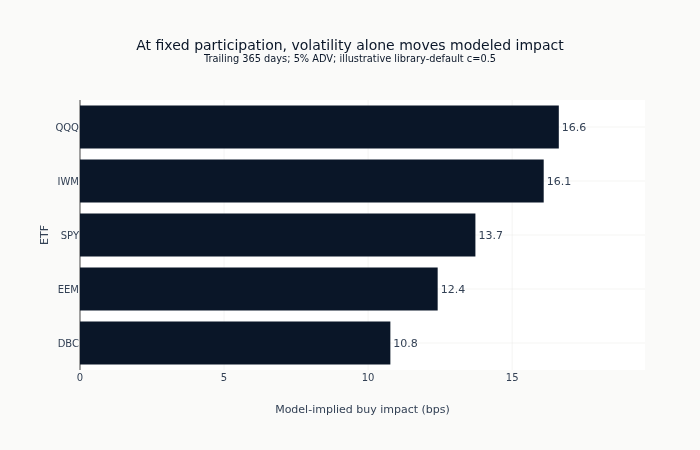

In [25]:
expected_bps = (
    IMPACT_COEFFICIENT
    * parameterized_impact["daily_volatility"]
    * np.sqrt(PARAMETERIZATION_PARTICIPATION)
    * 10_000
)
if not np.allclose(parameterized_impact["impact_bps"].to_numpy(), expected_bps.to_numpy()):
    raise ValueError("Library impact disagrees with the closed-form square-root expression")

impact_fig = go.Figure()
impact_fig.add_bar(
    x=parameterized_impact["impact_bps"].to_list(),
    y=parameterized_impact["symbol"].to_list(),
    orientation="h",
    marker_color=COLORS["blue"],
    text=[f"{value:.1f}" for value in parameterized_impact["impact_bps"]],
    textposition="outside",
)
impact_fig.update_layout(
    title=(
        "At fixed participation, volatility alone moves modeled impact"
        "<br><sup>Trailing 365 days; 5% ADV; illustrative library-default c=0.5</sup>"
    ),
    xaxis_title="Model-implied buy impact (bps)",
    yaxis_title="ETF",
    height=450,
    margin=dict(r=55),
)
impact_fig.update_xaxes(range=[0, parameterized_impact["impact_bps"].max() * 1.18])
show_plotly_with_alt(
    impact_fig,
    "A horizontal bar per ETF of model-implied impact in basis points, sorted ascending and "
    "labelled with its value. The range across the five funds is roughly threefold.",
)

In [26]:
lowest_impact = parameterized_impact.row(0, named=True)
highest_impact = parameterized_impact.row(-1, named=True)
display(
    Markdown(
        f"**Reading the chart:** With the coefficient held at {IMPACT_COEFFICIENT:.1f} and "
        f"participation fixed at {PARAMETERIZATION_PARTICIPATION:.0%}, modeled impact runs from "
        f"**{lowest_impact['impact_bps']:.1f} bps** for {lowest_impact['symbol']} to "
        f"**{highest_impact['impact_bps']:.1f} bps** for {highest_impact['symbol']}. Price and "
        "volume cancel at a fixed participation rate, so the ordering is the ordering of the five "
        "volatilities and nothing else. That is a property of the model, not a finding about "
        "these funds: it would hold whatever coefficient was chosen."
    )
)

**Reading the chart:** With the coefficient held at 0.5 and participation fixed at 5%, modeled impact runs from **10.8 bps** for DBC to **16.6 bps** for QQQ. Price and volume cancel at a fixed participation rate, so the ordering is the ordering of the five volatilities and nothing else. That is a property of the model, not a finding about these funds: it would hold whatever coefficient was chosen.

## Part 7: Cross-Model Impact at Increasing Order Sizes

The reference price and volume are round numbers rather than one of the ETFs, because the point
of the table is the spread between the four models at a common set of participation rates, and a
round price makes the basis-point arithmetic checkable by eye. The four columns are four
assumptions, priced identically; the differences between them are what a reader should stress
test before choosing one for a backtest.

In [27]:
# Summary comparison table
summary_data = []
reference_price = 100.0
reference_volume = 1_000_000.0

test_scenarios = [
    ("Small trade (1% ADV)", 0.01),
    ("Medium trade (5% ADV)", 0.05),
    ("Large trade (10% ADV)", 0.10),
    ("Very large (20% ADV)", 0.20),
]

test_models = {
    "NoImpact": NoImpact(),
    "Linear (0.1)": LinearImpact(coefficient=0.1),
    "SqRt (2% vol)": SquareRootImpact(
        coefficient=IMPACT_COEFFICIENT, volatility=SCENARIO_VOLATILITY
    ),
    "Power (0.6)": PowerLawImpact(coefficient=0.1, exponent=0.6),
}

for scenario, participation in test_scenarios:
    row = {"Scenario": scenario}
    qty = reference_volume * participation

    for model_name, model in test_models.items():
        impact = model.calculate(qty, reference_price, reference_volume, is_buy=True)
        impact_bps = impact / reference_price * 10_000
        row[model_name] = f"{impact_bps:.1f} bps"

    summary_data.append(row)

summary_df = pl.DataFrame(summary_data)
summary_df

Scenario,NoImpact,Linear (0.1),SqRt (2% vol),Power (0.6)
str,str,str,str,str
"""Small trade (1% ADV)""","""0.0 bps""","""10.0 bps""","""10.0 bps""","""63.1 bps"""
"""Medium trade (5% ADV)""","""0.0 bps""","""50.0 bps""","""22.4 bps""","""165.7 bps"""
"""Large trade (10% ADV)""","""0.0 bps""","""100.0 bps""","""31.6 bps""","""251.2 bps"""
"""Very large (20% ADV)""","""0.0 bps""","""200.0 bps""","""44.7 bps""","""380.7 bps"""


**Finding**: The cross-model table keeps price, volume, and participation identical. Its level
differences therefore reflect model assumptions and parameter conventions, which should be
stress-tested rather than mistaken for observed execution costs.

## Key Takeaways

1. **Add a signed impact to the decision price exactly once.** The models return a positive move
   for buys and a negative one for sells, so the arithmetic is the same on both sides and a sign
   error shows up as a fill that is better than the decision price. Check that direction on a
   sell order before trusting any cost number built on it.

2. **An exponent and a coefficient are not independent, so a level comparison between two models
   means nothing until they are matched somewhere.** Two of the curves in Part 3 have the same
   square-root shape and sit at different levels purely because their coefficients follow
   different conventions. Pick a participation rate, match the models there, and compare what is
   left.

3. **Size orders as a share of volume, not as a share count.** Participation is what every impact
   model consumes and what a volume cap acts on, and it is the only quantity comparable across
   instruments whose volumes differ by orders of magnitude.

4. **A backtest must carry the unfilled remainder.** Capping participation means some orders fill
   partially, and a backtest that quietly fills the whole order anyway has assumed away the
   constraint it just imposed.

5. **Substituting a measured volatility into a model whose coefficient you assumed is not
   calibration.** The ETF section changes one input and holds the other fixed, so what it shows
   is the model's own volatility sensitivity. Estimating the coefficient needs execution records,
   as `03_market_impact_calibration` sets out.

6. **These models have no memory, so persistence is the caller's job.** Each call sees one order.
   A parent order worked in slices needs the permanent part of each slice's impact carried into
   the next slice's reference price, and this notebook does that itself rather than expecting the
   model to.

7. **Reproduce a library result a second way before building on it.** Part 5 recomputes the
   square-root impact from the closed form and raises if the two disagree, which is what makes
   the rest of the section evidence rather than trust.

### Known limitations

- The impact coefficients throughout are stated, including the library defaults. Every cost level
  in the notebook scales directly with them and none of them was fitted to executions.
- Impact is charged against average daily volume, so the intraday variation that
  `03_market_impact_calibration` measured is absent: the same order at the same participation
  costs the same at noon as at the open.
- The persistence assumption in Part 4 is a flat fraction applied uniformly. Real permanent
  impact depends on how much information the trading reveals, which varies by order and by name.
- The five ETFs are a fixed retrospective sample over the trailing year, chosen for a spread of
  volatilities rather than sampled from anything.
- `ExecutionResult.adjusted_price` and `impact_cost` are populated by the notebook's own helper.
  The production `FillExecutor` applies impact to the base price and emits a `Fill`; the fields
  on the limit's own result are placeholders.

**Next**: `07_ml4t_volume_participation` takes the participation cap used here and shows what it
does to a parent order across many bars; `10_gross_vs_net_performance` puts these models into a
full backtest.

**Book**: Chapter 18, Section 18.4.